In [1]:
import os
import os.path as osp
from pathlib import Path
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

In [2]:
!nvidia-smi

Sun Nov  3 07:10:33 2024       
+---------------------------------------------------------------------------------------+
| NVIDIA-SMI 535.183.01             Driver Version: 535.183.01   CUDA Version: 12.2     |
|-----------------------------------------+----------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |         Memory-Usage | GPU-Util  Compute M. |
|                                         |                      |               MIG M. |
|=========================================+======================+======================|
|   0  NVIDIA GeForce RTX 4070 Ti     Off | 00000000:01:00.0  On |                  N/A |
|  0%   39C    P5              17W / 285W |    838MiB / 12282MiB |      3%      Default |
|                                         |                      |                  N/A |
+-----------------------------------------+----------------------+--

 ### Load metadata 

In [3]:

IMAGE_DIR_TRAIN = "/storage/plzen4-ntis/home/silvador386/Vision/datasets/danishfungi/FungiTastic/train/720p"
IMAGE_DIR_VAL = "/storage/plzen4-ntis/home/silvador386/Vision/datasets/danishfungi/FungiTastic/val/720p"
IMAGE_DIR_TEST = "/storage/plzen4-ntis/home/silvador386/Vision/datasets/danishfungi/FungiTastic/test/720p"

TRAIN_METADATA_PATH = "/storage/plzen4-ntis/home/silvador386/Vision/datasets/danishfungi/metadata/FungiTastic-Mini/FungiTastic-Mini-Train.csv"
TEST_METADATA_CLOSED_PATH = "/storage/plzen4-ntis/home/silvador386/Vision/datasets/danishfungi/metadata/FungiTastic-Mini/FungiTastic-Mini-ClosedSet-Val.csv"
TEST_METADATA_OPEN_PATH = "/storage/plzen4-ntis/home/silvador386/Vision/datasets/danishfungi/metadata/FungiTastic-Mini/FungiTastic-Mini-OpenSet-Val.csv"

In [4]:
updated_train_metadata_path = osp.join(osp.dirname(TRAIN_METADATA_PATH), Path(TRAIN_METADATA_PATH).stem + "-updated.csv")
updated_test_metadata_closed_path = osp.join(osp.dirname(TEST_METADATA_CLOSED_PATH), Path(TEST_METADATA_CLOSED_PATH).stem + "-updated.csv")
updated_test_metadata_open_path = osp.join(osp.dirname(TEST_METADATA_OPEN_PATH), Path(TEST_METADATA_OPEN_PATH).stem + "-updated.csv")

In [5]:
from sklearn.preprocessing import LabelEncoder


# le = LabelEncoder()
# le.fit(pd.read_csv(TRAIN_METADATA_PATH).scientificName)

image_dirs = [IMAGE_DIR_TRAIN, IMAGE_DIR_VAL, IMAGE_DIR_VAL]
default_metadata_paths = [TRAIN_METADATA_PATH, TEST_METADATA_CLOSED_PATH, TEST_METADATA_OPEN_PATH]
updated_metadata_paths = [updated_train_metadata_path, updated_test_metadata_closed_path, updated_test_metadata_open_path]
dfs = []

# Function to safely transform with -1 for unseen labels
# def safe_transform(le, labels):
#     known_classes = set(le.classes_)
#     return [le.transform([label])[0] if label in known_classes else -1 for label in labels]


for image_dir, default_path, updated_path in zip(image_dirs, default_metadata_paths, updated_metadata_paths):
    if osp.exists(updated_path):
        print("Loading metadta:", updated_path)
        dfs.append(pd.read_csv(updated_path))
        continue
    
    df = pd.read_csv(default_path)
    df["image_path"] = df.filename.apply(
        lambda path: osp.join(image_dir, osp.basename(path)))

    df["class_id"] = df["category_id"]

    df_mask = df.image_path.apply(
        lambda path: osp.exists(path))
    print("Files missing:", len(df) - sum(df_mask))
    df = df[df_mask]

    print("Num. classes,", len(df["class_id"].unique()))
    df.to_csv(updated_path, index=False)
    dfs.append(df)
                   
train_df, test_closed_df, test_open_df = dfs        


Loading metadta: /storage/plzen4-ntis/home/silvador386/Vision/datasets/danishfungi/metadata/FungiTastic-Mini/FungiTastic-Mini-Train-updated.csv
Loading metadta: /storage/plzen4-ntis/home/silvador386/Vision/datasets/danishfungi/metadata/FungiTastic-Mini/FungiTastic-Mini-ClosedSet-Val-updated.csv
Loading metadta: /storage/plzen4-ntis/home/silvador386/Vision/datasets/danishfungi/metadata/FungiTastic-Mini/FungiTastic-Mini-OpenSet-Val-updated.csv


### Environment variables
Select which GPU to use and add your WANDB_ENTITY and WANDB_PROJECT you want to log into.

In [6]:
# os.environ["TRAIN_METADATA_PATH"] = updated_train_metadata_path 
# os.environ["TEST_METADATA_PATH"] = updated_test_metadata_path 

# %env CUDA_DEVICES = 0
# %env WANDB_ENTITY = mhanzl
# %env WANDB_PROJECT = FGVC-Test
# # Optional
# # %env HFHUB_OWNER = changethis

# os.environ["CUDA_VISIBLE_DEVICES"] = os.environ["CUDA_DEVICES"]

### Test model

In [7]:
import sys
import os
%load_ext autoreload
%autoreload 2

SCRIPT_DIR = os.path.dirname(os.path.abspath(os.getcwd()))
sys.path.append(os.path.dirname(SCRIPT_DIR))

In [8]:
import logging
import os
import sys

import numpy as np
import pandas as pd
from sklearn.metrics import classification_report

from fgvc.core.training import predict
from fgvc.datasets import get_dataloaders
from fgvc.special.threshold_analysis import (
    class_wise_confidence_threshold_report,
    estimate_optimal_confidence_thresholds,
)
from fgvc.utils.experiment import load_args, load_model, load_test_metadata
from fgvc.utils.utils import set_cuda_device
from fgvc.utils.wandb import log_summary_scores, resume_wandb, wandb
from fgvc.losses import RecallatKSurrogate

logger = logging.getLogger("script")


In [9]:
def add_arguments(parser):
    """Callback function that includes metadata args."""
    parser.add_argument(
        "--test-metadata",
        help="Path to a test metadata file.",
        type=str,
        required=True,
    )
    parser.add_argument(
        "--ignore-unfinished",
        help="Do not check if the W&B run is finished and run evaluation either way.",
        action="store_true",
    )
    parser.add_argument(
        "--rerun",
        help="Re-runs evaluation on test set even if the run already has test scores.",
        action="store_true",
    )
    parser.add_argument(
        "--label-col",
        help="Name of column with target classes (labels) in the test set.",
        type=str,
        default=None,
    )


def classification_report_df(
        test_df: pd.DataFrame, preds: np.ndarray, targs: np.ndarray, label_col: str = None
) -> pd.DataFrame:
    """Create classification report with class-wise Precision, Recall, and F1 score metrics.

    The method is based on the `sklearn.metrics.classification_report` method.
    """
    report_df = pd.DataFrame.from_dict(
        classification_report(
            targs,
            preds.argmax(1),
            labels=np.arange(preds.shape[1]),
            zero_division=0,
            output_dict=True,
        ),
        orient="index",
    )
    report_df.index.name = "class_id"
    report_df = report_df.reset_index()
    report_df = report_df.rename(
        columns={
            "precision": "Precision",
            "recall": "Recall",
            "f1-score": "F1",
            "support": "Num Records",
        }
    )
    if label_col is not None:
        id2label = dict(zip(test_df["class_id"].astype(str), test_df[label_col]))
        report_df.insert(1, label_col, report_df["class_id"].apply(id2label.get))
    return report_df


def threhold_analysis_report_df(
        test_df: pd.DataFrame, preds: np.ndarray, targs: np.ndarray, label_col: str = None
) -> pd.DataFrame:
    """Create threshold analysis report with class-wise confidence thresholds and metrics."""
    confidence_thresholds = estimate_optimal_confidence_thresholds(preds, targs)
    report_df = class_wise_confidence_threshold_report(preds, targs, confidence_thresholds)
    report_df.index.name = "class_id"
    report_df = report_df.reset_index()
    if label_col is not None:
        id2label = dict(zip(test_df["class_id"].astype(str), test_df[label_col]))
        report_df.insert(1, label_col, report_df["class_id"].apply(id2label.get))
    return report_df

In [17]:

cuda_devices = 0
label_col = "class_id"
wandb_run_path = "mhanzl/FGVC-Test/14m2l4j3"

###

# set device
device = set_cuda_device(cuda_devices)

train_df = train_df
test_closed_df = test_closed_df
test_open_df = test_open_df
if label_col is not None:
    assert label_col in test_closed_df, f"Test dataframe is missing column '{label_col}'."

# connect to wandb and load run
logger.info(f"Loading W&B experiment run: {wandb_run_path}")
api = wandb.Api()
run = api.run(wandb_run_path)
config = run.config
config["contrastive"] = True

exp_path = osp.join(".", "experiment", run.config["exp_path"].lstrip("../"))

# load model
model_filename = os.path.join(exp_path, "best_recall@1.pth")
logger.info(f"Loading fine-tuned model. Using model checkpoint from the file: {model_filename}")
model, model_mean, model_std = load_model(config, checkpoint_path=model_filename)

# create dataloaders
logger.info("Creating DataLoaders.")
trainloader, testloader, _, _ = get_dataloaders(
    train_df,
    test_closed_df,
    augmentations=config["augmentations"],
    image_size=config["image_size"],
    model_mean=model_mean,
    model_std=model_std,
    batch_size=config["batch_size"],
    num_workers=config["workers"],
)

_, openloader, _, _ = get_dataloaders(
    None,
    test_open_df,
    augmentations=config["augmentations"],
    image_size=config["image_size"],
    model_mean=model_mean,
    model_std=model_std,
    batch_size=config["batch_size"],
    num_workers=config["workers"],
)


    # run inference
logger.info("Evaluating the model.")

trainer_kws = {"criterion": RecallatKSurrogate}

train_preds, train_targs, _, train_scores = predict(model, trainloader, device=device, criterion=RecallatKSurrogate(batch_size=128))
test_preds, test_targs, _, test_scores = predict(model, testloader, device=device, criterion=RecallatKSurrogate(batch_size=128))
open_preds, open_targs, _, open_scores = predict(model, openloader, device=device, criterion=RecallatKSurrogate(batch_size=128))
# test_preds

# # log scores
# scores_str = "\t".join([f"{k}: {v:.2%}" for k, v in scores.items()])
# logger.info(f"Scores - {scores_str}")
# logger.info("Logging scores to wandb.")
# log_summary_scores(wandb_run_path, test_scores=scores, allow_new=True, prefix="Test. ")

# # resume W&B run and log classification report to W&B
# resume_wandb(run_id=run.id, entity=run.entity, project=run.project)
# clf_report_df = classification_report_df(test_df, preds, targs, label_col=label_col)
# th_report_df = threhold_analysis_report_df(test_df, preds, targs, label_col=label_col)


(fgvc) INFO: Using device: cuda (0)
(fgvc) INFO: Device names: 0: NVIDIA A40
(script) INFO: Loading W&B experiment run: mhanzl/FGVC-Test/14m2l4j3
(script) INFO: Loading fine-tuned model. Using model checkpoint from the file: ./experiment/runs/vit_base_patch16_224_in21k-RecallatKSurrogate-vit_heavy/exp2/best_recall@1.pth
(fgvc) INFO: Using ContrastiveViT model.
(fgvc) DEBUG: Loading pre-trained checkpoint.
(script) INFO: Creating DataLoaders.
(script) INFO: Evaluating the model.


  0%|          | 0/19 [00:00<?, ?it/s]

  0%|          | 0/19 [00:00<?, ?it/s]

In [12]:
train_scores

{'NMI': 0.9040388679876336,
 'Recall@1': 0.9447566943773641,
 'Recall@2': 0.9641613061782746,
 'Recall@4': 0.9748894065351655,
 'Recall@8': 0.9806595003526168}

In [18]:
test_scores

{'NMI': 0.742498513554568,
 'Recall@1': 0.7540931320433766,
 'Recall@2': 0.81554327025303,
 'Recall@4': 0.8623219221773336,
 'Recall@8': 0.8928343610461408}

In [21]:
open_scores

{'NMI': 0.740395499076811,
 'Recall@1': 0.7519059720457433,
 'Recall@2': 0.8132147395171537,
 'Recall@4': 0.8604404913172384,
 'Recall@8': 0.8913595933926303}

In [5]:
from typing import Tuple, Union
import warnings
from typing import Optional, Sequence, Tuple, Union

import numpy as np
import sklearn.metrics as metrics
from scipy.special import expit
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    multilabel_confusion_matrix,
    top_k_accuracy_score,
)
import matplotlib.pyplot as plt

import faiss



class KNNClassifier:
    
    def __init__(self, embeddings_dim, n_classes, **kwargs):
        self.embeddings_dim = embeddings_dim
        self.n_classes = n_classes        
        self.kmeans = faiss.Clustering(self.embeddings_dim, self.n_classes)
        self.kmeans.niter = kwargs.get("niter", 40)
        self.kmeans.min_points_per_centroid = kwargs.get("min_points_per_centroid", 1)
        self.kmeans.max_points_per_centroid = kwargs.get("max_points_per_centroid", 1000000000)
        
    def fit(self, preds, targs):
        cpu_cluster_index = faiss.IndexFlatL2(self.embeddings_dim)
        self.kmeans.train(preds, cpu_cluster_index)
        self.train_preds = preds
        self.train_targs = targs

    
    def predict(self, preds, k_values, threshold = None):
        computed_centroids = faiss.vector_float_to_array(self.kmeans.centroids).reshape(
            self.n_classes, self.embeddings_dim
        )
        faiss_search_index = faiss.IndexFlatL2(computed_centroids.shape[-1])
        faiss_search_index.add(computed_centroids)
        distances, model_generated_cluster_labels = faiss_search_index.search(preds, 1)  # Classes

        # print("Max distance", max(distances))
        # plt.figure(figsize=(8, 6))
        # plt.hist(distances, bins=100, color='skyblue', edgecolor='black')
        # plt.title('Histogram of Distances to Nearest Centroid')
        # plt.xlabel('Distance')
        # plt.ylabel('Frequency')
        # plt.grid(True)
        # plt.show()
        
        # If threshold is provided, compare distances to threshold and set predictions to -1 if too far
        if threshold is not None:
            # Assign -1 for points with distance greater than the threshold
            model_generated_cluster_labels[distances > threshold] = -1
        
        faiss_search_index = faiss.IndexFlatL2(self.embeddings_dim)
        faiss_search_index.add(preds)
        _, k_closest_points = faiss_search_index.search(preds, int(np.max(k_values) + 1))
        
        faiss_search_index = faiss.IndexFlatL2(self.embeddings_dim)
        faiss_search_index.add(self.train_preds)
        _, k_closest_points_train = faiss_search_index.search(preds, int(np.max(k_values) + 1))
             
        
        return model_generated_cluster_labels, k_closest_points, k_closest_points_train
        

def _faiss_clustering(
        preds: np.ndarray, n_classes: int, k_values, **kwargs
    ) -> Tuple:
    cpu_cluster_index = faiss.IndexFlatL2(preds.shape[-1])
    
    
    kmeans = faiss.Clustering(preds.shape[-1], n_classes)
    kmeans.niter = kwargs.get("niter", 20)
    kmeans.min_points_per_centroid = kwargs.get("min_points_per_centroid", 1)
    kmeans.max_points_per_centroid = kwargs.get("max_points_per_centroid", 1000000000)
    kmeans.train(preds, cpu_cluster_index)
    computed_centroids = faiss.vector_float_to_array(kmeans.centroids).reshape(
        n_classes, preds.shape[-1]
    )
    faiss_search_index = faiss.IndexFlatL2(computed_centroids.shape[-1])
    faiss_search_index.add(computed_centroids)
    _, model_generated_cluster_labels = faiss_search_index.search(preds, 1)
    faiss_search_index = faiss.IndexFlatL2(preds.shape[-1])
    faiss_search_index.add(preds)
    _, k_closest_points = faiss_search_index.search(preds, int(np.max(k_values) + 1))
    return model_generated_cluster_labels, k_closest_points

clustering_fn = _faiss_clustering

kmeans = KNNClassifier(embeddings_dim=config["embeddings_dim"], n_classes=config["number_of_classes"])
kmeans.fit(train_preds, train_targs)

NameError: name 'config' is not defined

In [4]:
def cluster_classification_scores(
    preds: np.ndarray,
    targs: np.ndarray,
    k_values: tuple,
    *,
    return_dict: bool = True,
    clustering_kws: dict = None,
) -> Union[dict, Tuple]:

    n_classes = len(np.unique(targs))
    preds = np.vstack(preds).astype("float32")
    targs = np.hstack(targs).reshape(-1, 1)
    clustering_kws = clustering_kws or {}
    # model_generated_cluster_labels, k_closest_points = clustering_fn(
    #     preds, n_classes, k_values, **clustering_kws
    # )
    
    model_generated_cluster_labels, k_closest_points, k_closest_points_train = kmeans.predict(preds, k_values, threshold=0.95)
    acc = accuracy_score(targs, model_generated_cluster_labels)
    # print("Accuracy", acc)

    
    nmi_score = metrics.cluster.normalized_mutual_info_score(
        model_generated_cluster_labels.reshape(-1), targs.reshape(-1)
    )
    k_closest_classes = targs.reshape(-1)[k_closest_points[:, 1:]]
    recall_all_k = []
    for k in k_values:
        recall_at_k = np.sum(
            [
                1
                for target, recalled_predictions in zip(targs, k_closest_classes)
                if target in recalled_predictions[:k]
            ]
        ) / len(targs)
        recall_all_k.append(recall_at_k)
        
    k_closest_classes_train = train_targs.reshape(-1)[k_closest_points_train[:, 1:]]
    for k in k_values:
        recall_at_k = np.sum(
            [
                1
                for target, recalled_predictions in zip(train_targs, k_closest_classes_train)
                if target in recalled_predictions[:k]
            ]
        ) / len(train_targs)
        print("train recall", k, recall_at_k)


    if return_dict:
        scores = {"NMI": nmi_score}
        for k, recall in zip(k_values, recall_all_k):
            scores[f"Recall@{k}"] = recall
    else:
        scores = nmi_score, *recall_all_k

    return scores

# print(cluster_classification_scores(test_preds, test_targs, k_values = [1, 3, 8]))
print(cluster_classification_scores(open_preds, open_targs, k_values = [1, 3, 8]))

NameError: name 'np' is not defined

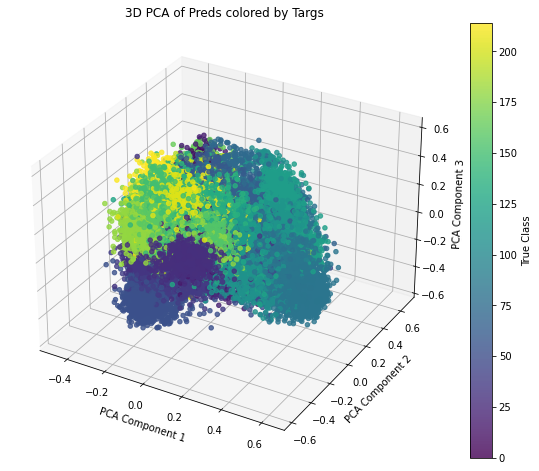

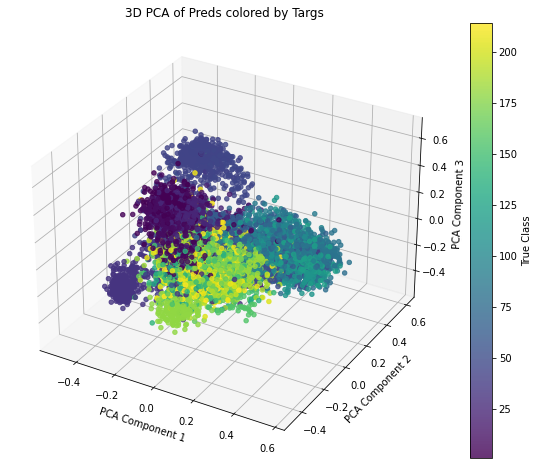

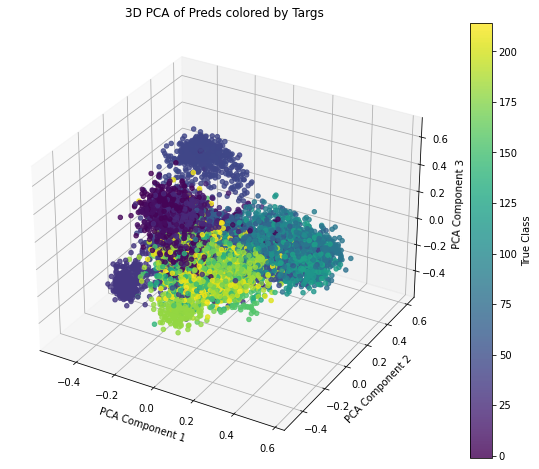

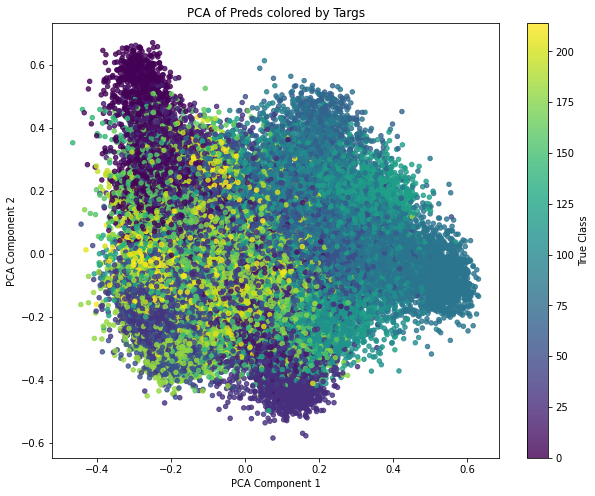

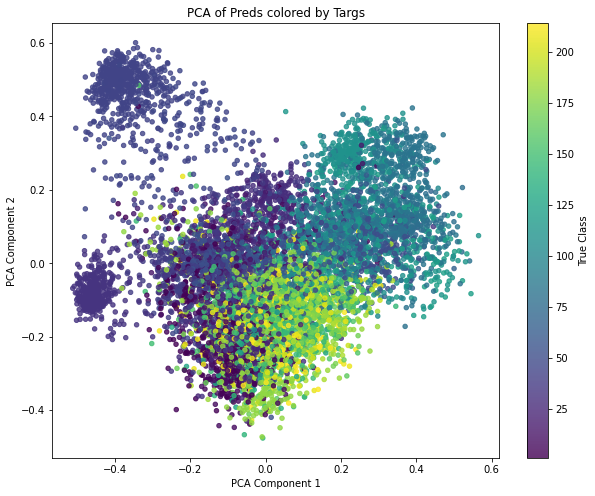

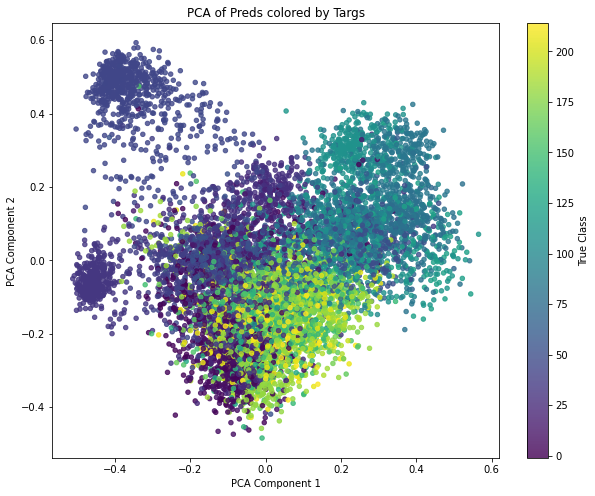

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import seaborn as sns

def plot_pca(preds: np.ndarray, targs: np.ndarray):
    # Step 1: Apply PCA to reduce preds to 2 components
    pca = PCA(n_components=3)
    preds_pca = pca.fit_transform(preds)

    # Step 2: Plot the PCA components, color-coded by targs
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')

    # Step 3: Scatter plot with 3 PCA components and color based on targs
    scatter = ax.scatter(preds_pca[:, 0], preds_pca[:, 1], preds_pca[:, 2], c=targs, cmap='viridis', s=20, alpha=0.8)

    # Step 4: Add labels and color bar
    ax.set_title('3D PCA of Preds colored by Targs')
    ax.set_xlabel('PCA Component 1')
    ax.set_ylabel('PCA Component 2')
    ax.set_zlabel('PCA Component 3')
    fig.colorbar(scatter, ax=ax, label='True Class')

    # Step 4: Show plot
    plt.show()
    
def plot_pca_2d(preds: np.ndarray, targs: np.ndarray):
    # Step 1: Apply PCA to reduce preds to 2 components
    pca = PCA(n_components=2)
    preds_pca = pca.fit_transform(preds)

    # Step 2: Plot the PCA components, color-coded by targs
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(preds_pca[:, 0], preds_pca[:, 1], c=targs, cmap='viridis', s=20, alpha=0.8)

    # Step 3: Add colorbar and labels
    plt.colorbar(scatter, label='True Class')
    plt.title('PCA of Preds colored by Targs')
    plt.xlabel('PCA Component 1')
    plt.ylabel('PCA Component 2')

    # Step 4: Show plot
    plt.show()    
    

# Example usage
plot_pca(train_preds, train_targs)
plot_pca(test_preds, test_targs)
plot_pca(open_preds, open_targs)

plot_pca_2d(train_preds, train_targs)
plot_pca_2d(test_preds, test_targs)
plot_pca_2d(open_preds, open_targs)


## Running Sweep Training 

In [ ]:
# Change sweep configuration if needed
# !wandb sweep ../sweep_configs/DF24M_224.yaml

In [ ]:
# !wandb agent <WANDB_ENTITY>/<WANDB_PROJECT>...